In [1]:
import pandas as pd

In [5]:
data=pd.read_csv('Clustering_gmm (2).csv')

In [6]:
data.describe()

,Weight,Height
count,500.000000,500.000000
mean,61.270240,169.515781
std,5.196976,4.805095
min,50.433644,160.182164
25%,57.772791,166.607599
50%,61.961518,169.726252
75%,65.439332,172.837284
max,70.700456,178.894770


In [8]:
data.isnull().sum()

Weight    0
Height    0
dtype: int64

In [ ]:
#A common rule is:min_samples = 2 × number_of_features
#min_samples=4
#eps-We usually use a K-Distance Graph.


In [12]:
from sklearn.preprocessing import StandardScaler
x=data
std=StandardScaler()
std_x=std.fit_transform(x)
std_x


array([[ 1.11574234,  1.3687876 ],
       [ 1.45111317,  1.84840758],
       [-0.06536808,  0.16013941],
       [-0.2959289 , -0.17161237],
       [ 0.80145801,  0.88492583],
       [ 0.05911672, -0.296655  ],
       [ 0.39902082,  0.2347225 ],
       [-0.04403045,  0.12101381],
       [ 0.26260451,  0.48896883],
       [-1.51439123, -1.4080276 ],
       [ 0.32126978, -0.16784452],
       [ 1.40310706,  1.44948945],
       [ 0.74980181,  0.34597958],
       [-1.50704162, -1.37504543],
       [-0.11766033,  0.2357939 ],
       [-0.40326956, -0.06769819],
       [ 1.13518021,  1.42101652],
       [-0.12388934,  0.06923305],
       [-1.40712459, -1.46350113],
       [-0.17532489,  0.07812177],
       [-0.27223219, -0.13771991],
       [ 1.30159605,  1.57477649],
       [ 0.63973502,  0.11396353],
       [-1.48674485, -1.51216605],
       [-0.15856049,  0.10257674],
       [-1.24029136, -1.19702075],
       [ 1.54831057,  1.58236443],
       [ 0.2816594 , -0.08551459],
       [-1.36435166,

In [13]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt


In [14]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(std_x)

distances, indices = neighbors_fit.kneighbors(std_x)

In [15]:
distances = np.sort(distances[:,4])

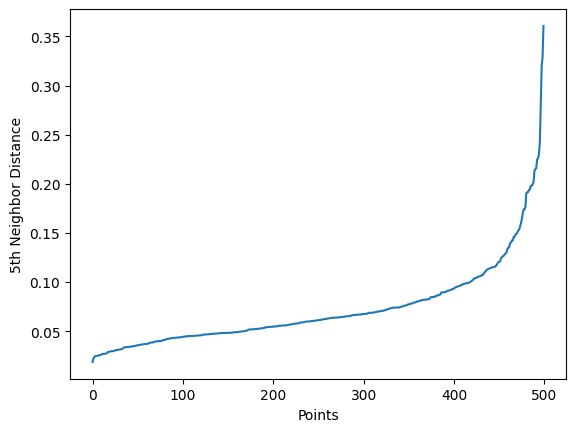

In [16]:
plt.plot(distances)
plt.xlabel("Points")
plt.ylabel("5th Neighbor Distance")
plt.show()

In [ ]:
#If the bend occurs around: eps = 0.35

In [17]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=0.35,
    min_samples=5
)

In [18]:
pred=dbscan.fit_predict(std_x)

In [19]:
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,

In [21]:
data['Cluster'] = pred
print(data['Cluster'].value_counts())

Cluster
0    375
1    125
Name: count, dtype: int64
